In [1]:
%pip install -q librosa pandas numpy matplotlib soundfile kagglehub
%pip install -q pathlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import librosa
import glob
from pathlib import Path
import kagglehub

In [3]:
BASE_DIR = Path('/kaggle/input/competitions/birdclef-2026')
TRAIN_AUDIO_DIR = BASE_DIR / 'train_audio'
TRAIN_SOUNDSCAPES_DIR = BASE_DIR / 'train_soundscapes'

In [4]:
# 2. Load Core Metadata
# Essential for mapping audio files to species labels [cite: 9, 21]
train_df = pd.read_csv(BASE_DIR / 'train.csv') 
# Provides common names and higher-level classification (e.g., Insecta) [cite: 15, 21]
taxonomy_df = pd.read_csv(BASE_DIR / 'taxonomy.csv') 
# Template for the required final output format [cite: 32, 29]
sample_sub = pd.read_csv(BASE_DIR / 'sample_submission.csv')

In [5]:
# 3. Global Constants
# Standardized sampling rate mentioned in the dataset description 
SR = 32000 
# Every audio recording in the test set is split into 5-second windows [cite: 28, 34]
WINDOW_SIZE = 5

In [6]:
print(f"Loaded {len(train_df)} training records across {train_df['primary_label'].nunique()} species.")

Loaded 35549 training records across 206 species.


In [7]:
import librosa.display
import matplotlib.pyplot as plt

In [8]:
# 1. Select a sample file from the training metadata
sample_row = train_df.iloc[0]
sample_path = TRAIN_AUDIO_DIR/sample_row['filename']

# 2. Load the file using our standardized sampling rate
# We load just 5 seconds to match the test window size
y, sr = librosa.load(sample_path, sr=SR, duration=WINDOW_SIZE)

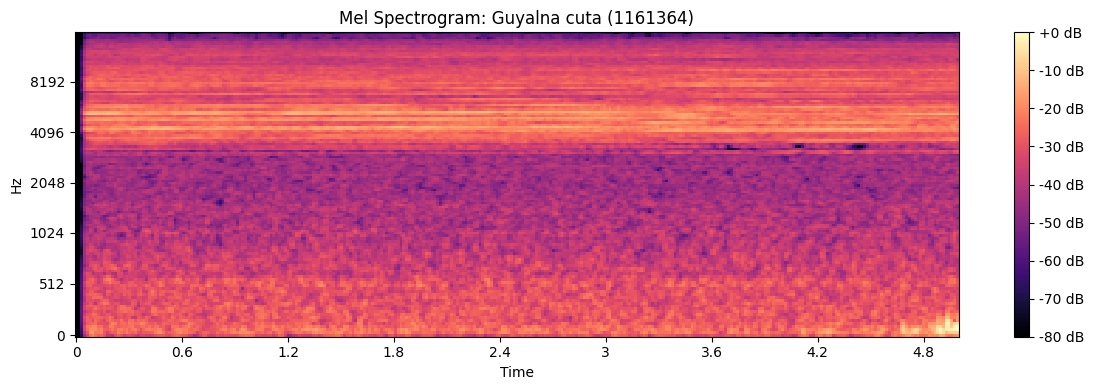

In [9]:
# 3. Create the Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
S_dB = librosa.power_to_db(S, ref=np.max)

# 4. Plotting
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=16000)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram: {sample_row['common_name']} ({sample_row['primary_label']})")
plt.tight_layout()
plt.show()

### Saves a sound file as a numpy vector file in a directory of your choice

More precisely, saves a 2D NumPy representation of the processed audio (mel spectrogram)

In [10]:
import numpy as np
import librosa
from pathlib import Path

# 1. Create a directory for the processed features
PROCESSED_DIR = Path('processed_features_storage_dir')
PROCESSED_DIR.mkdir(exist_ok=True)

def encode_audio_to_spectrogram(row, save_dir):
    """Loads audio, converts to Mel Spectrogram, and invokes normalization."""
    try:
        # Load exactly 5 seconds to match WINDOW_SIZE
        file_path = TRAIN_AUDIO_DIR / row['filename']
        y, _ = librosa.load(file_path, sr=SR, duration=WINDOW_SIZE)
        
        # Pad with zeros if the audio is shorter than 5 seconds
        if len(y) < SR * WINDOW_SIZE:
            y = np.pad(y, (0, SR * WINDOW_SIZE - len(y)))

        # Generate Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128, fmax=16000)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Invoke the separate normalization method
        # S_normalized = normalize_spectrogram(S_dB)

        # Save as a compact .npy file
        save_name = Path(row['filename']).stem + '.npy'
        np.save(save_dir / save_name, S_dB)
        return True
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")
        return False

### Process a small batch (e.g., the first 50 files) using the above method

In [11]:
test_batch = train_df.head(50)
print(f"Starting batch processing for {len(test_batch)} files...")

success_count = 0
for _, row in test_batch.iterrows():
    if encode_audio_to_spectrogram(row, PROCESSED_DIR):
        success_count += 1

print(f"Finished! Successfully encoded {success_count} files into {PROCESSED_DIR}/")

Starting batch processing for 50 files...
Finished! Successfully encoded 50 files into processed_features_storage_dir/


### Runs spectrogram conversion pipeline over the full dataset and saves one .npy feature file per audio clip.

In [12]:
from tqdm.auto import tqdm
import time

# 1. Clear out previous test run if desired, or skip existing files
'''
'''
def process_full_dataset(df, save_dir):
    success_count = 0
    # tqdm creates a functional progress bar in your notebook
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Encoding Audio"):
        save_name = Path(row['filename']).stem + '.npy'
        save_path = save_dir / save_name
        
        # Skip if already processed (resumable)
        if save_path.exists():
            success_count += 1
            continue
 
        if encode_audio_to_spectrogram(row, save_dir):
            success_count += 1
            
    return success_count


In [13]:
class DatasetManager:
    """Manages the lifecycle of spectrogram features: detection, generation, and upload."""
    
    def __init__(self, dataset_handle: str, local_work_dir: str):
        self.handle = dataset_handle
        self.local_dir = Path(local_work_dir)
        
        # Derive Kaggle input path: /kaggle/input/datasets/<owner>/<slug>
        owner, slug = self.handle.split('/')
        self.kaggle_input_dir = Path('/kaggle/input/datasets')/owner/slug

    def get_dataset_source(self) -> Path:
        """Determines if we should use existing Kaggle data or local workspace."""
        if self.kaggle_input_dir.exists() and any(self.kaggle_input_dir.glob('*.npy')):
            print(f"✅ Found Kaggle Dataset: {self.handle}")
            print(f"   Using path: {self.kaggle_input_dir}")
            return self.kaggle_input_dir
        
        print(f"📂 Dataset not found at {self.kaggle_input_dir}. Using local workspace: {self.local_dir}")
        self.local_dir.mkdir(exist_ok=True)
        return self.local_dir

    def process_and_upload(self, dataframe, force_rebuild=False):
        """Orchestrates the generation and Kaggle upload logic."""
        source_dir = self.get_dataset_source()
        
        # If we are using the Kaggle input dir, we can't write to it (read-only)
        if source_dir == self.kaggle_input_dir and not force_rebuild:
            print("⏭️  Skipping generation — Dataset already exists on Kaggle.")
            return source_dir

        # 1. Generate Features
        total_encoded = process_full_dataset(dataframe, self.local_dir)
        generated_files = list(self.local_dir.glob('*.npy'))
        
        print(f"📊 Generation Complete: {len(generated_files)}/{len(dataframe)} files ready.")

        # 2. Validation & Upload
        if len(generated_files) == len(dataframe):
            self._upload_to_kaggle()
        else:
            print(f"⚠️  Count mismatch ({len(generated_files)} vs {len(dataframe)}). Upload aborted.")
        
        return self.local_dir

    def _upload_to_kaggle(self):
        """Handles the kagglehub upload protocol using positional arguments."""
        print(f"🚀 Uploading to Kaggle: {self.handle}...")
        try:
            # handle -> positional 1
            # local_dataset_dir -> positional 2
            kagglehub.dataset_upload(
                self.handle, 
                str(self.local_dir.resolve()), 
                version_notes=f"Processed {len(list(self.local_dir.glob('*.npy')))} features. n_mels=128, SR=32000",
                ignore_patterns=["*.tmp", "__pycache__/"]
            )
            print(f"✅ Upload successful: https://www.kaggle.com/datasets/{self.handle}")
        except Exception as e:
            print(f"❌ Upload failed: {e}")

# =========================
# EXECUTION
# =========================
manager = DatasetManager(
    dataset_handle='gany24558/encoded-spectrograms-npy',
    local_work_dir='processed_features_working_dir'
)

# This will now automatically decide whether to generate or just link paths
PROCESSED_DIR = manager.process_and_upload(train_df)


✅ Found Kaggle Dataset: gany24558/encoded-spectrograms-npy
   Using path: /kaggle/input/datasets/gany24558/encoded-spectrograms-npy
⏭️  Skipping generation — Dataset already exists on Kaggle.


### Encoding: convert the bird species labels (strings) into integer IDs that the model can use.

In [14]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
encoder = LabelEncoder()

# 2. Fit on ALL 234 species from taxonomy_df
all_species = sorted(taxonomy_df['primary_label'].astype(str).unique())
encoder.fit(all_species)

# 3. Apply primary label → integer id list
# "houspa" -> [123]
train_df['primary_label_ids'] = train_df['primary_label'].apply(
    lambda x: [int(encoder.transform([str(x)])[0])]
)

# 4. Save mapping
species_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

# ── SECONDARY LABELS (quick win — no retraining needed) ──────────────────────
# train.csv has a 'secondary_labels' column like "['sp1', 'sp2']" or "[]".
# We parse it into a list of integer ids so BirdDataset can set them at 0.5
# weight in the label vector.  No audio changes, no extra .npy files needed.

def parse_secondary_ids(cell, encoder_classes_set):
    """
    Parse a secondary_labels cell from train.csv into a list of integer ids.
    Handles both JSON-list strings '["sp1","sp2"]' and empty '[]' / NaN.
    Only keeps species that exist in the encoder (all 234 taxonomy species).
    """
    import ast
    if not isinstance(cell, str) or cell.strip() in ('', '[]'):
        return []
    try:
        labels = ast.literal_eval(cell)   # safely parse the Python-list string
    except Exception:
        labels = [s.strip() for s in cell.split()]   # fallback: space-separated
    ids = []
    for sp in labels:
        sp = str(sp).strip()
        if sp in encoder_classes_set:
            ids.append(int(encoder.transform([sp])[0]))
    return ids

encoder_classes_set = set(encoder.classes_)
train_df['secondary_label_ids'] = train_df['secondary_labels'].apply(
    lambda x: parse_secondary_ids(x, encoder_classes_set)
)

# Soundscape rows won't have secondary labels — give them an empty list
# (handled when we build soundscape_df later)

n_with_secondary = (train_df['secondary_label_ids'].apply(len) > 0).sum()
print(f"Mapped {len(species_mapping)} species to integer labels.")
print(f"Rows with ≥1 secondary label : {n_with_secondary} / {len(train_df)}")
print(
    f"Example primary  : "
    f"{train_df.iloc[0]['primary_label']} "
    f"→ {train_df.iloc[0]['primary_label_ids']}"
)
print(f"Example secondary: {train_df.iloc[0]['secondary_labels']} → {train_df.iloc[0]['secondary_label_ids']}")



Mapped 234 species to integer labels.
Rows with ≥1 secondary label : 4372 / 35549
Example primary  : 1161364 → [0]
Example secondary: [] → []


In [15]:
#----------Use ratings and Weight -----------------------
# 1. Handle missing or NaN ratings (if any)
train_df['rating'] = train_df['rating'].fillna(0.0)

# 2. Convert to weights using Square Root Scaling
# Rating 1.0 -> Weight 1.41
# Rating 5.0 -> Weight 2.45
# This reduces the max influence gap from 5x down to ~1.7x
train_df['weight'] = train_df['rating'].apply(lambda x: np.sqrt(float(x) + 1.0))

# 3. Quick sanity check
print(f"Weight distribution in train_df:")
print(train_df['weight'].value_counts().sort_index())
print(f"Average weight: {train_df['weight'].mean():.2f}")


Weight distribution in train_df:
weight
1.000000    12849
1.224745       22
1.414214      147
1.581139      120
1.732051      598
1.870829      518
2.000000     2738
2.121320     1509
2.236068     8018
2.345208     2185
2.449490     6845
Name: count, dtype: int64
Average weight: 1.79


In [16]:
column_to_check = 'weight'

if column_to_check in train_df.columns:
    print(f"✅ '{column_to_check}' is present in the DataFrame.")
else:
    print(f"❌ '{column_to_check}' is MISSING.")

✅ 'weight' is present in the DataFrame.


In [17]:
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


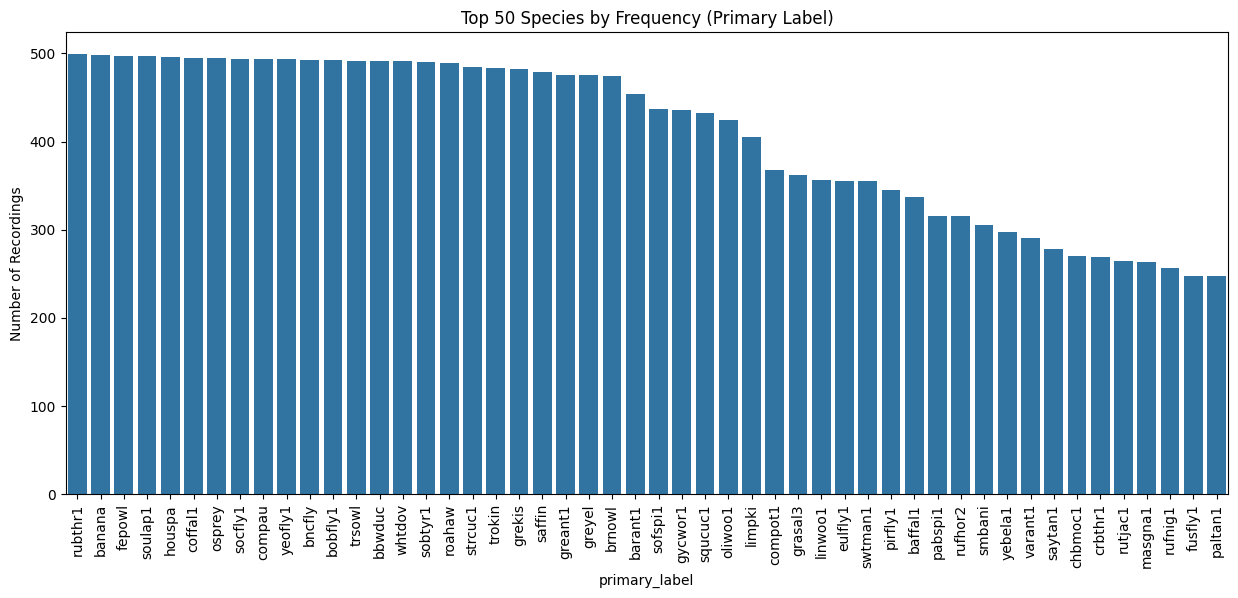

Most frequent species: rubthr1 (499 files)
Least frequent species: 23150 (1 files)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count occurrences per species
species_counts = train_df['primary_label'].value_counts()

# 2. Plot the distribution
plt.figure(figsize=(15, 6))
sns.barplot(x=species_counts.index[:50], y=species_counts.values[:50])
plt.xticks(rotation=90)
plt.title("Top 50 Species by Frequency (Primary Label)")
plt.ylabel("Number of Recordings")
plt.show()

print(f"Most frequent species: {species_counts.index[0]} ({species_counts.max()} files)")
print(f"Least frequent species: {species_counts.index[-1]} ({species_counts.min()} files)")

In [19]:
# 1. Define a target minimum number of samples per species
TARGET_MIN = 50

# 2. Create a balanced dataframe
balanced_list = []
for label in train_df['primary_label'].unique():
    species_group = train_df[train_df['primary_label'] == label]

    if len(species_group) < TARGET_MIN:
        oversampled_group = species_group.sample(TARGET_MIN, replace=True, random_state=42)
        balanced_list.append(oversampled_group)
    else:
        balanced_list.append(species_group)

balanced_df = pd.concat(balanced_list).reset_index(drop=True)

print(f"Original Dataset: {len(train_df)} records")
print(f"Balanced Dataset: {len(balanced_df)} records")
print(f"Minimum samples per species now: {balanced_df['primary_label'].value_counts().min()}")


Original Dataset: 35549 records
Balanced Dataset: 37376 records
Minimum samples per species now: 50


In [20]:
import os

print("Kaggle input folders:\n")

for path in sorted(os.listdir('/kaggle/input')):
    print(path)

import os

print(os.listdir('/kaggle/input/datasets'))
print(os.listdir('/kaggle/input/datasets/gany24558'))

Kaggle input folders:

competitions
datasets
['gany24558']
['encoded-spectrograms-npy', 'birdclef-groundtruth-soundscape-composite-pl', 'birdclef2026-s22-pseudolabels']


In [21]:
# =========================
# LOAD SOUNDSCAPE MANIFEST
# =========================

import json

# ⚠️ NEW DATASET HANDLE - /kaggle/input/datasets/gany24558/birdclef-groundtruth-soundscape-composite-pl
# E.g. /kaggle/input/datasets/gany24558/birdclef-groundtruth-soundscape-composite-pl/BC2026_Train_0001_S08_20250606_030007__s00-00-00_e00-00-05.npy
NEW_SOUNDSCAPE_HANDLE = 'gany24558/birdclef-groundtruth-soundscape-composite-pl'

_sc_parts = NEW_SOUNDSCAPE_HANDLE.split('/')

# Correct Kaggle input path
SOUNDSCAPE_BASE = (
    Path('/kaggle/input/datasets')
    / _sc_parts[0]
    / _sc_parts[1]
)

SOUNDSCAPE_MANIFEST = SOUNDSCAPE_BASE / 'soundscape_manifest.csv'

if not SOUNDSCAPE_MANIFEST.exists():
    raise FileNotFoundError(
        f"Soundscape manifest not found at {SOUNDSCAPE_MANIFEST}\n"
        f"Make sure dataset '{NEW_SOUNDSCAPE_HANDLE}' is attached."
    )

# =========================
# LOAD MANIFEST
# =========================
soundscape_df = pd.read_csv(SOUNDSCAPE_MANIFEST)

# Prepend full path to .npy files
soundscape_df['filename'] = (
    str(SOUNDSCAPE_BASE) + '/' + soundscape_df['filename']
)

print(SOUNDSCAPE_BASE)
print(SOUNDSCAPE_MANIFEST)
print(SOUNDSCAPE_MANIFEST.exists())

# =========================
# PRIMARY LABEL IDS
# =========================
# primary_label column now contains:
# '["sp1", "sp2", "sp3"]'

def parse_primary_label_ids(cell):
    try:
        labels = json.loads(cell)

        if not isinstance(labels, list):
            labels = [labels]

        ids = []

        for sp in labels:
            sp = str(sp)

            if sp in encoder_classes_set:
                ids.append(
                    int(encoder.transform([sp])[0])
                )

        return ids

    except Exception:
        return []

soundscape_df['primary_label_ids'] = (
    soundscape_df['primary_label']
    .apply(parse_primary_label_ids)
)

# =========================
# SECONDARY LABEL IDS
# =========================
# Composite labels are already handled in primary_label_ids
# so secondary labels stay empty

soundscape_df['secondary_label_ids'] = [
    [] for _ in range(len(soundscape_df))
]

# =========================
# MARK AS NPY
# =========================
soundscape_df['is_npy'] = True

# =========================
# SAMPLE WEIGHTS
# =========================
# Give soundscapes strong influence

soundscape_df['weight'] = np.sqrt(5.0 + 1.0)

print(
    f"Assigned weight "
    f"{soundscape_df['weight'].iloc[0]:.2f} "
    f"to soundscapes."
)

# =========================
# DEBUG / INFO
# =========================

# Count unique species across composite arrays
all_species = []

for ids in soundscape_df['primary_label_ids']:
    all_species.extend(ids)

unique_species_count = len(set(all_species))

print(f'Soundscape dataset path : {SOUNDSCAPE_BASE}')
print(f'Soundscape samples      : {len(soundscape_df)}')
print(f'Soundscape species      : {unique_species_count}')

print('\nSample rows:')
print(
    soundscape_df[
        ['filename', 'primary_label', 'primary_label_ids']
    ].head(3)
)

/kaggle/input/datasets/gany24558/birdclef-groundtruth-soundscape-composite-pl
/kaggle/input/datasets/gany24558/birdclef-groundtruth-soundscape-composite-pl/soundscape_manifest.csv
True
Assigned weight 2.45 to soundscapes.
Soundscape dataset path : /kaggle/input/datasets/gany24558/birdclef-groundtruth-soundscape-composite-pl
Soundscape samples      : 739
Soundscape species      : 75

Sample rows:
                                            filename  \
0  /kaggle/input/datasets/gany24558/birdclef-grou...   
1  /kaggle/input/datasets/gany24558/birdclef-grou...   
2  /kaggle/input/datasets/gany24558/birdclef-grou...   

                                       primary_label         primary_label_ids  
0  ["47158son13", "47158son17", "47158son22", "47...      [42, 46, 51, 52, 54]  
1  ["47158son13", "47158son17", "47158son21", "47...  [42, 46, 50, 51, 52, 54]  
2  ["47158son13", "47158son17", "47158son21", "47...  [42, 46, 50, 51, 52, 54]  


#### The analysis notebook shows that some of the worst performing species, were 3 frogs which were not present in train.csv (isolated), but present in the soundscape file (Chorus). So pick the smallest chorus sets, and over sample them. They are the closest to train.csv type files

In [22]:
# =========================
# OVERSAMPLE RARE AMPHIBIANS
# Target species with zero clean training clips
# Only use windows with ≤ 2 species (near-isolated signal)
# =========================

RARE_AMPHIBIANS = {'517063', '1491113', '25073'}
MAX_SPECIES_IN_WINDOW = 2
OVERSAMPLE_FACTOR = 10

def get_raw_labels(cell):
    """Parse primary_label JSON back to raw string set."""
    try:
        labels = json.loads(cell)
        return {str(l) for l in labels}
    except Exception:
        return set()

def is_clean_rare_window(cell):
    labels = get_raw_labels(cell)
    has_rare = bool(labels & RARE_AMPHIBIANS)
    is_small = len(labels) <= MAX_SPECIES_IN_WINDOW
    return has_rare and is_small

clean_rare_mask = soundscape_df['primary_label'].apply(is_clean_rare_window)
clean_rare_df   = soundscape_df[clean_rare_mask].copy()

# Report what was found per species
print("=" * 60)
print("CLEAN WINDOWS FOR RARE AMPHIBIANS (≤ 2 species)")
print("=" * 60)
for sp in RARE_AMPHIBIANS:
    sp_mask  = clean_rare_df['primary_label'].apply(
        lambda x: sp in get_raw_labels(x)
    )
    sp_count = sp_mask.sum()
    combos   = (
        clean_rare_df[sp_mask]['primary_label']
        .value_counts()
        .head(5)
    )
    print(f"\n  {sp} — {sp_count} clean windows found:")
    for combo, cnt in combos.items():
        print(f"    {combo}  ×{cnt}")

if len(clean_rare_df) == 0:
    print("\n⚠️  No clean windows found. "
          "Consider increasing MAX_SPECIES_IN_WINDOW to 3.")
else:
    oversampled_df = pd.concat(
        [clean_rare_df] * OVERSAMPLE_FACTOR
    ).reset_index(drop=True)

    soundscape_df = pd.concat(
        [soundscape_df, oversampled_df]
    ).reset_index(drop=True)

    print(f"\nOversample factor      : {OVERSAMPLE_FACTOR}×")
    print(f"Clean windows found    : {len(clean_rare_df)}")
    print(f"Oversampled rows added : {len(oversampled_df)}")
    print(f"Total soundscape rows  : {len(soundscape_df)}")

CLEAN WINDOWS FOR RARE AMPHIBIANS (≤ 2 species)

  1491113 — 14 clean windows found:
    ["1491113"]  ×7
    ["1491113", "517063"]  ×7

  25073 — 0 clean windows found:

  517063 — 51 clean windows found:
    ["517063"]  ×18
    ["1491113", "517063"]  ×7
    ["22973", "517063"]  ×7
    ["517063", "litnig1"]  ×5
    ["517063", "65380"]  ×4

Oversample factor      : 10×
Clean windows found    : 58
Oversampled rows added : 580
Total soundscape rows  : 1319


# Adding the pseudo labelled soundscape data from the S22 region

Since the S22 pseudo-label dataset has a different manifest format:

filename,start,end,primary_label
BC2026_Train_xxx__0000.npy,00:00:00,00:00:05,22961;23158;24321

and primary_label is a semicolon-separated string rather than a JSON list, you'll need a slightly different parser.

In [23]:
# =========================
# LOAD S22 PSEUDO-LABELLED SOUNDSCAPES
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

# Dataset handle
S22_SOUNDSCAPE_HANDLE = (
    "gany24558/birdclef2026-s22-pseudolabels"
)

_sc_parts = S22_SOUNDSCAPE_HANDLE.split("/")

# Correct Kaggle input path
S22_SOUNDSCAPE_BASE = (
    Path("/kaggle/input/datasets")
    / _sc_parts[0]
    / _sc_parts[1]
)

S22_MANIFEST = (
    S22_SOUNDSCAPE_BASE / "0000_soundscape_manifest.csv"
)

if not S22_MANIFEST.exists():
    raise FileNotFoundError(
        f"S22 manifest not found at {S22_MANIFEST}\n"
        f"Make sure dataset '{S22_SOUNDSCAPE_HANDLE}' is attached."
    )

# =========================
# LOAD MANIFEST
# =========================

s22_soundscape_df = pd.read_csv(S22_MANIFEST)

# Prepend full path to .npy files
s22_soundscape_df["filename"] = (
    str(S22_SOUNDSCAPE_BASE)
    + "/"
    + s22_soundscape_df["filename"]
)

print(S22_SOUNDSCAPE_BASE)
print(S22_MANIFEST)
print(S22_MANIFEST.exists())

# =========================
# PRIMARY LABEL IDS
# =========================
# primary_label format:
# 65380;22973;517063

def parse_s22_primary_label_ids(cell):

    if pd.isna(cell):
        return []

    labels = [
        x.strip()
        for x in str(cell).split(";")
        if x.strip()
    ]

    ids = []

    for sp in labels:

        if sp in encoder_classes_set:

            ids.append(
                int(
                    encoder.transform([sp])[0]
                )
            )

    return ids


s22_soundscape_df["primary_label_ids"] = (
    s22_soundscape_df["primary_label"]
    .apply(parse_s22_primary_label_ids)
)

# =========================
# SECONDARY LABEL IDS
# =========================

s22_soundscape_df["secondary_label_ids"] = [
    [] for _ in range(len(s22_soundscape_df))
]

# =========================
# MARK AS NPY
# =========================

s22_soundscape_df["is_npy"] = True

# =========================
# SAMPLE WEIGHTS
# =========================
# Pseudo labels should have lower influence
# than real soundscape labels

s22_soundscape_df["weight"] = 0.25

print(
    f"Assigned pseudo-label weight "
    f"{s22_soundscape_df['weight'].iloc[0]:.2f}"
)

# =========================
# DEBUG / INFO
# =========================

all_species = []

for ids in s22_soundscape_df["primary_label_ids"]:
    all_species.extend(ids)

unique_species_count = len(set(all_species))

print(
    f"S22 dataset path    : {S22_SOUNDSCAPE_BASE}"
)
print(
    f"S22 samples         : {len(s22_soundscape_df):,}"
)
print(
    f"S22 species         : {unique_species_count}"
)

print("\nLabels per chunk:")
print(
    s22_soundscape_df["primary_label_ids"]
    .str.len()
    .describe()
)

print("\nSample rows:")
print(
    s22_soundscape_df[
        [
            "filename",
            "primary_label",
            "primary_label_ids",
            "weight"
        ]
    ].head(3)
)

/kaggle/input/datasets/gany24558/birdclef2026-s22-pseudolabels
/kaggle/input/datasets/gany24558/birdclef2026-s22-pseudolabels/0000_soundscape_manifest.csv
True
Assigned pseudo-label weight 0.25
S22 dataset path    : /kaggle/input/datasets/gany24558/birdclef2026-s22-pseudolabels
S22 samples         : 15,951
S22 species         : 32

Labels per chunk:
count    15951.000000
mean         2.565795
std          0.658044
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          3.000000
Name: primary_label_ids, dtype: float64

Sample rows:
                                            filename       primary_label  \
0  /kaggle/input/datasets/gany24558/birdclef2026-...        517063;65380   
1  /kaggle/input/datasets/gany24558/birdclef2026-...        517063;65380   
2  /kaggle/input/datasets/gany24558/birdclef2026-...  517063;65380;22967   

  primary_label_ids  weight  
0          [57, 63]    0.25  
1          [57, 63]    0.25  
2       [57, 63, 9]    

In [24]:
from sklearn.model_selection import train_test_split

balanced_df['is_npy'] = False

# Propagate secondary_label_ids through the balanced/oversampled dataframe
# (already present since balanced_df is sampled from train_df)

train_df_split, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['primary_label'],
    random_state=42
)

val_df['is_npy'] = False

# 3. Handle Val Split Weights 
# Even though we won't use them for loss, we add them to keep the DataFrame schema consistent
val_df['weight'] = np.sqrt(1.0 + 1.0) # Baseline weight of 1.41


In [25]:
print("\nDATASET SUMMARY")

print(f"Train split (actual)   : {len(train_df_split):,}")
print(f"GT soundscapes         : {len(soundscape_df):,}")
print(f"S22 pseudo soundscapes : {len(s22_soundscape_df):,}")
print(f"Validation split       : {len(val_df):,}")
print(f"Total training samples : {len(balanced_df):,}")

print(
    f"Composition (%)        : "
    f"Real={100 * len(train_df_split) / len(balanced_df):.1f}, "
    f"GT={100 * len(soundscape_df) / len(balanced_df):.1f}, "
    f"Pseudo={100 * len(s22_soundscape_df) / len(balanced_df):.1f}"
)


DATASET SUMMARY
Train split (actual)   : 29,900
GT soundscapes         : 1,319
S22 pseudo soundscapes : 15,951
Validation split       : 7,476
Total training samples : 37,376
Composition (%)        : Real=80.0, GT=3.5, Pseudo=42.7


In [26]:
# =========================
# ADD SOUNDSCAPE DATA and Pseudo-labelled S22 SOUNDSCAPE DATA TO TRAINING SPLIT
# Validation stays clean — only original train_audio samples
# =========================

train_df_split = pd.concat([
    train_df_split[['filename', 'primary_label', 'primary_label_ids',
                    'secondary_label_ids', 'is_npy', 'weight']],
    soundscape_df[['filename', 'primary_label', 'primary_label_ids',
                   'secondary_label_ids', 'is_npy', 'weight']],
    s22_soundscape_df[['filename', 'primary_label', 'primary_label_ids',
                       'secondary_label_ids', 'is_npy', 'weight']]
]).reset_index(drop=True)

print("\nDATASET SUMMARY")
print(f"Train split (actual)   : {len(train_df_split) - len(soundscape_df) - len(s22_soundscape_df):,}")
print(f"GT soundscapes         : {len(soundscape_df):,}")
print(f"S22 pseudo soundscapes : {len(s22_soundscape_df):,}")
print(f"Combined train split   : {len(train_df_split):,}")
print(f"Validation split       : {len(val_df):,}")



DATASET SUMMARY
Train split (actual)   : 29,900
GT soundscapes         : 1,319
S22 pseudo soundscapes : 15,951
Combined train split   : 47,170
Validation split       : 7,476


### Load the saved spectrograms, converts them into tensors, and batches them so that the model can train efficiently.

In [27]:
import random
import torch
from torch.utils.data import Dataset, DataLoader

# Weight applied to secondary species in the label vector.
# 0.5 means the model learns "this species was probably there" without
# treating it as confidently as the primary label (1.0).
SECONDARY_LABEL_WEIGHT = 0.5

class BirdDataset(Dataset):
    def __init__(self, df, processed_dir, num_classes=234, mixup_count=5000, transform=None):
        self.df           = df
        self.processed_dir = processed_dir
        self.num_classes  = num_classes
        self.transform    = transform
        self.base_len     = len(df)
        self.mixup_count  = mixup_count

    def __len__(self):
        return self.base_len + self.mixup_count

    def get_label(self, row):
        """
        Build a soft multi-label vector.
    
        Primary labels   → 1.0
        Secondary labels → SECONDARY_LABEL_WEIGHT
    
        Supports:
        - normal train.csv rows
        - composite soundscape rows
        """
    
        label_vec = np.zeros(
            self.num_classes,
            dtype=np.float32
        )
    
        # ==========================================
        # PRIMARY LABELS
        # ==========================================
        primary_ids = row.get('primary_label_ids', [])
    
        # Safety: handle scalar accidentally passed
        if not isinstance(primary_ids, list):
            primary_ids = [primary_ids]
    
        for pid in primary_ids:
    
            if 0 <= pid < self.num_classes:
    
                label_vec[pid] = 1.0
    
        # ==========================================
        # SECONDARY LABELS
        # ==========================================
        sec_ids = row.get('secondary_label_ids', [])
    
        if isinstance(sec_ids, list):
    
            for sid in sec_ids:
    
                if 0 <= sid < self.num_classes:
    
                    # Don't overwrite primary labels
                    label_vec[sid] = max(
                        label_vec[sid],
                        SECONDARY_LABEL_WEIGHT
                    )
    
        return label_vec
    
    def _load_image(self, row):
        """Load mel spectrogram — supports both train_audio and soundscape .npy."""        
        if row['is_npy']:
            return np.load(row['filename'])
        else:
            return np.load(self.processed_dir / f"{Path(row['filename']).stem}.npy")

    def __getitem__(self, idx):
            # CASE 1: Normal sample
            if idx < self.base_len:
                row    = self.df.iloc[idx]
                image  = self._load_image(row)
                label  = self.get_label(row)
                weight = row['weight']  # <--- NEW: Extract sample weight
    
            # CASE 2: MixUp sample
            else:
                valid_indices = self.df.index[
                    self.df['is_npy'] == False
                ].tolist()
                
                idx1 = random.choice(valid_indices)
                idx2 = random.choice(valid_indices)
                    
                row1 = self.df.iloc[idx1]
                row2 = self.df.iloc[idx2]
    
                img1 = self._load_image(row1)
                img2 = self._load_image(row2)
                lbl1 = self.get_label(row1)
                lbl2 = self.get_label(row2)
                
                # GET WEIGHTS FOR BOTH SAMPLES
                w1 = row1['weight']
                w2 = row2['weight']
    
                lam   = np.random.beta(1.0, 1.0)
                image = lam * img1 + (1 - lam) * img2
                label = lam * lbl1 + (1 - lam) * lbl2
                
                # MIX THE WEIGHTS (Weighted interpolation of confidence)
                weight = lam * w1 + (1 - lam) * w2
    
            image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
            label_tensor = torch.tensor(label, dtype=torch.float32)
            weight_tensor = torch.tensor(weight, dtype=torch.float32) # <--- NEW TENSOR
    
            if self.transform:
                image_tensor = self.transform(image_tensor)
    
            # Return the trio: image, label, and its importance weight
            return image_tensor, label_tensor, weight_tensor


In [28]:
from torchaudio.transforms import FrequencyMasking, TimeMasking
import torch.nn as nn

spec_aug = nn.Sequential(
    FrequencyMasking(freq_mask_param=24),
    TimeMasking(time_mask_param=64),
)


train_dataset = BirdDataset(
    train_df_split,
    PROCESSED_DIR,
    mixup_count=5000,
    transform=spec_aug # keep mixup here
)

val_dataset = BirdDataset(
    val_df,
    PROCESSED_DIR,
    mixup_count=0      # ❗ disable mixup
)

In [29]:
# Initialize the DataLoader
# batch_size=32 is a safe starting point for MacBook Air memory
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Test one batch
features, labels, weights = next(iter(train_loader))
print(f"Batch Shape: {features.shape}") # Expect [32, 1, 128, 313]
print(f"Labels Shape: {labels.shape}")     # Expect [32]

Batch Shape: torch.Size([32, 1, 128, 313])
Labels Shape: torch.Size([32, 234])


### Construct the Neural Net Architecture

In [30]:
%pip install -q timm

import timm
import torch.nn as nn

Note: you may need to restart the kernel to use updated packages.


In [31]:
class BirdModel(nn.Module):
    def __init__(self, num_classes):
        super(BirdModel, self).__init__()
        # 1. Load a pre-trained EfficientNet-B0
        # in_chans=1 because our spectrograms are grayscale (1 channel)
        self.backbone = timm.create_model('efficientnet_b3', 
                                          pretrained=True, 
                                          num_classes=0, 
                                          in_chans=1)
        
        # 2. Get the number of features from the backbone output
        num_features = self.backbone.num_features
        
        # 3. Define the final classification head
        self.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x

# Initialize the model
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# Universal device selector: prioritizes NVIDIA GPU, then Apple Silicon, then CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)

# Optional but recommended for NVIDIA GPUs: optimizes convolution algorithms
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print(f"Using device: {device}")

model = BirdModel(num_classes=234).to(device)

print(f"Model initialized on: {device}")

Using device: cuda


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model initialized on: cuda


In [32]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'DONT_UPLOAD_THIS'

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import os

# =========================
# 1. Hyperparameters
# =========================
EPOCHS = 35

# Max training limit — early stopping will likely trigger before this

EARLY_STOPPING_PATIENCE = 6
# Increased from 5 → gives the model more room to improve before stopping
# Important because LR is still high in early epochs, so temporary plateaus are expected

EARLY_STOPPING_MIN_DELTA = 1e-4
# Minimum improvement to reset patience counter
# Filters out noise — tiny fluctuations don't count as real improvement

# =========================
# 2. Loss and Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss(reduction='none')
# Correct loss for multi-label classification + mixup
# Expects raw logits (not sigmoid-ed outputs)

optimizer = optim.Adam([
    {"params": model.backbone.parameters(), "lr": 1e-5},
    # Small LR for pretrained backbone — preserves learned ImageNet features
    # Slightly increased from 1e-5 to allow faster adaptation to bird spectrograms

    {"params": model.fc.parameters(), "lr": 1e-4},
    # Larger LR for classifier head — trained from scratch so can afford bigger steps
    # Maintains 10x ratio over backbone LR (standard best practice)
])

# =========================
# 3. Scheduler
# =========================
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    # First cosine cycle runs for 10 epochs — LR decays from max → eta_min
    # Aligns with expected early stopping window (~6-10 epochs)

    T_mult=1,
    # Each restart uses the same cycle length (10 epochs)
    # If training continues past epoch 10, the LR resets and decays again
    # Prevents the flat eta_min problem of plain CosineAnnealingLR

    eta_min=1e-6
    # Floor LR — allows fine-grained weight updates at end of each cycle
)

# =========================
# 3. Training Loop
# =========================
print(f"Starting training for {EPOCHS} epochs...")
best_val_loss = float('inf')
save_dir = "soundscape_v1_may_4"
os.makedirs(save_dir, exist_ok=True)

# Early stopping state
epochs_no_improve = 0
early_stopped = False

for epoch in range(EPOCHS):
    # -------------------------
    # TRAINING PHASE
    # -------------------------
    model.train()
    running_loss = 0.0
    current_lr = scheduler.get_last_lr()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train] LR={current_lr}")

    for i, (inputs, labels, weights) in enumerate(pbar):
        inputs = inputs.to(device)
        labels = labels.to(device)
        weights = weights.to(device) # Move weights to GPU/MPS

        optimizer.zero_grad()
        outputs = model(inputs)
        
        raw_loss = criterion(outputs, labels)

        # Normalize weights so the batch average is 1.0 (prevents gradient explosion)
        weights = weights / weights.mean()
        
        # Apply weights and take the mean
        # unsqueeze(1) aligns [Batch] weights to [Batch, Classes] loss
        loss = (raw_loss * weights.unsqueeze(1)).mean()
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=running_loss / (i + 1))

    avg_train_loss = running_loss / len(train_loader)
    scheduler.step()

    # -------------------------
    # VALIDATION PHASE
    # -------------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for val_inputs, val_labels, _ in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)
            val_outputs = model(val_inputs)
            v_loss = criterion(val_outputs, val_labels).mean()
            val_loss += v_loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # -------------------------
    # EARLY STOPPING CHECK
    # -------------------------
    if avg_val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        # Genuine improvement — reset patience counter
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_save_path = os.path.join(save_dir, "bird_model_best.pth")
        torch.save(model.state_dict(), best_save_path)
        print(f"  ✅ Val loss improved → {best_val_loss:.4f} | Saved Best Model")
        kagglehub.model_upload(
            'gany24558/birdclef-apr-20-2026-gc/PyTorch/backup', 
            'soundscape_v1_may_4/', 
            version_notes=f'Epoch {epoch+1} — val loss {best_val_loss:.4f}'
        )
    else:
        # No improvement
        epochs_no_improve += 1
        print(f"  ⚠️ No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}!")
            early_stopped = True

    # -------------------------
    # EPOCH SUMMARY
    # -------------------------
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f} | LR = {scheduler.get_last_lr()}")

    if early_stopped:
        break

# =========================
# 4. Save Final Model
# =========================
save_path = os.path.join(save_dir, "bird_model_final.pth")
torch.save(model.state_dict(), save_path)
print(f"\nFinal model saved at: {save_path}")

if early_stopped:
    print(f"Training stopped early at epoch {epoch+1}/{EPOCHS}")
    print(f"Best model (val loss: {best_val_loss:.4f}) saved at: {best_save_path}")
else:
    print(f"Training completed all {EPOCHS} epochs")
    print(f"Best val loss: {best_val_loss:.4f} | Best model saved at: {best_save_path}")


# =========================
# 5. UPLOAD BEST MODEL TO KAGGLE
# =========================
print(f"\nUploading best model to Kaggle...")
kagglehub.model_upload(
    'gany24558/birdclef-apr-20-2026-gc/PyTorch/rare-amphibian-oversample',
    save_dir,
    version_notes=f'B3 + 234 classes + soundscape + secondary labels — best val loss {best_val_loss:.4f}'
)
print(f"✅ Upload complete!")
print(f"Model available at: https://www.kaggle.com/models/gany24558/birdclef-apr-20-2026-gc/PyTorch/secondary-labels")

Starting training for 50 epochs...


Epoch 1/50 [Train] LR=[1e-05, 0.0001]:   0%|          | 0/1631 [00:00<?, ?it/s]

  ✅ Val loss improved → 0.0464 | Saved Best Model
Uploading Model https://api.kaggle.com/models/gany24558/birdclef-apr-20-2026-gc/PyTorch/backup ...
Starting upload for file soundscape_v1_may_4/bird_model_best.pth


Uploading: 100%|██████████| 44.8M/44.8M [00:01<00:00, 35.2MB/s]

Upload successful: soundscape_v1_may_4/bird_model_best.pth (43MB)


...

Uploading: 100%|██████████| 44.8M/44.8M [00:01<00:00, 33.9MB/s]

Upload successful: soundscape_v1_may_4/bird_model_final.pth (43MB)
Starting upload for file soundscape_v1_may_4/bird_model_best.pth



Uploading: 100%|██████████| 44.8M/44.8M [00:01<00:00, 34.7MB/s]

Upload successful: soundscape_v1_may_4/bird_model_best.pth (43MB)


Your model instance version has been created.
Files are being processed...
See at: https://api.kaggle.com/models/gany24558/birdclef-apr-20-2026-gc/PyTorch/rare-amphibian-oversample
✅ Upload complete!
Model available at: https://www.kaggle.com/models/gany24558/birdclef-apr-20-2026-gc/PyTorch/secondary-labels
